In [1]:
!pip install einops scikit-image gradio -q

In [2]:
import os, math, random, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from einops import rearrange
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim

def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Device: cuda
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
import os

# Deep explore
for root, dirs, files in os.walk('/kaggle/input/datasets'):
    print(root)
    if len(files) > 0:
        print('  files:', files[:3])
    break  # sirf top level

print(os.listdir('/kaggle/input/datasets/'))

/kaggle/input/datasets
['akash2sharma']


In [4]:
import os

# Correct path
base = '/kaggle/input/datasets/akash2sharma'
print(os.listdir(base))

['tiny-imagenet']


In [5]:
import os

TINY_IMAGENET_ROOT = '/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'

print('Contents:', os.listdir(TINY_IMAGENET_ROOT))
print('Train classes:', len(os.listdir(os.path.join(TINY_IMAGENET_ROOT, 'train'))))
print('Done ')

Contents: ['words.txt', 'wnids.txt', 'tiny-imagenet-200', 'val', 'test', 'train']
Train classes: 200
Done 


In [6]:
import shutil

IMG_SIZE    = 224
PATCH_SIZE  = 16
MASK_RATIO  = 0.75
BATCH_SIZE  = 32
NUM_EPOCHS  = 6
BASE_LR     = 1.5e-4
WEIGHT_DECAY= 0.05
WARMUP_EP   = 5
CLIP_GRAD   = 1.0
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
print(f'Total patches: {NUM_PATCHES} | Visible: {int(NUM_PATCHES*0.25)} | Masked: {int(NUM_PATCHES*0.75)}')

# Custom Dataset to handle TinyImageNet val structure
from torch.utils.data import Dataset
from PIL import Image

class TinyImageNetVal(Dataset):
    def __init__(self, val_path, transform=None):
        self.transform = transform
        self.samples = []
        ann_file = os.path.join(val_path, 'val_annotations.txt')
        img_dir  = os.path.join(val_path, 'images')
        classes  = sorted(os.listdir(os.path.join(TINY_IMAGENET_ROOT, 'train')))
        cls2idx  = {c:i for i,c in enumerate(classes)}
        with open(ann_file) as f:
            for line in f:
                p = line.strip().split('\t')
                img_path = os.path.join(img_dir, p[0])
                label    = cls2idx.get(p[1], 0)
                self.samples.append((img_path, label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = ImageFolder(os.path.join(TINY_IMAGENET_ROOT,'train'), transform=train_tfm)
val_ds   = TinyImageNetVal(os.path.join(TINY_IMAGENET_ROOT,'val'), transform=val_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Total patches: 196 | Visible: 49 | Masked: 147
Train: 100000 | Val: 10000


In [7]:
def sincos_pos_embed(dim, grid_size):
    assert dim % 4 == 0
    gx, gy = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
    gx = gx.reshape(-1); gy = gy.reshape(-1)
    half = dim // 4
    freq = 1.0 / (10000 ** (np.arange(half) / half))
    emb  = np.concatenate([
        np.sin(np.outer(gx,freq)), np.cos(np.outer(gx,freq)),
        np.sin(np.outer(gy,freq)), np.cos(np.outer(gy,freq))], axis=1)
    return torch.tensor(emb, dtype=torch.float32)

class Attention(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.heads=heads; self.hd=dim//heads; self.scale=self.hd**-0.5
        self.qkv=nn.Linear(dim,dim*3); self.proj=nn.Linear(dim,dim)
    def forward(self, x):
        B,N,C=x.shape
        qkv=self.qkv(x).reshape(B,N,3,self.heads,self.hd).permute(2,0,3,1,4)
        q,k,v=qkv.unbind(0)
        attn=(q@k.transpose(-2,-1)*self.scale).softmax(dim=-1)
        return self.proj((attn@v).transpose(1,2).reshape(B,N,C))

class Block(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        h=int(dim*4)
        self.n1=nn.LayerNorm(dim); self.att=Attention(dim,heads)
        self.n2=nn.LayerNorm(dim)
        self.ffn=nn.Sequential(nn.Linear(dim,h),nn.GELU(),nn.Linear(h,dim))
    def forward(self,x):
        x=x+self.att(self.n1(x)); x=x+self.ffn(self.n2(x)); return x

print('Blocks ready')

Blocks ready


In [8]:
class MAEEncoder(nn.Module):
    def __init__(self, img=224, p=16, c=3, dim=768, depth=12, heads=12):
        super().__init__()
        self.dim=dim; self.p=p
        self.embed=nn.Linear(p*p*c, dim)
        self.cls=nn.Parameter(torch.zeros(1,1,dim))
        self.register_buffer('pos', sincos_pos_embed(dim, img//p).unsqueeze(0))
        self.blocks=nn.ModuleList([Block(dim,heads) for _ in range(depth)])
        self.norm=nn.LayerNorm(dim)
        for m in self.modules():
            if isinstance(m,nn.Linear): nn.init.trunc_normal_(m.weight,std=0.02)
            if isinstance(m,nn.LayerNorm): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, vis, vis_ids):
        B=vis.size(0)
        x=self.embed(vis)
        pos_v=torch.gather(self.pos.expand(B,-1,-1),1,vis_ids.unsqueeze(-1).expand(-1,-1,self.dim))
        x=x+pos_v
        x=torch.cat([self.cls.expand(B,-1,-1), x], dim=1)
        for b in self.blocks: x=b(x)
        return self.norm(x)[:,1:]

print(f'Encoder params: {sum(p.numel() for p in MAEEncoder().parameters())/1e6:.1f}M')

Encoder params: 85.6M


In [9]:
class MAEDecoder(nn.Module):
    def __init__(self, N=196, enc_dim=768, dim=384, depth=12, heads=6, p=16, c=3):
        super().__init__()
        self.dim=dim; self.N=N
        self.proj=nn.Linear(enc_dim,dim)
        self.mask_tok=nn.Parameter(torch.zeros(1,1,dim))
        self.register_buffer('pos', sincos_pos_embed(dim, int(N**0.5)).unsqueeze(0))
        self.blocks=nn.ModuleList([Block(dim,heads) for _ in range(depth)])
        self.norm=nn.LayerNorm(dim)
        self.head=nn.Linear(dim, p*p*c)
        nn.init.trunc_normal_(self.mask_tok,std=0.02)
        for m in self.modules():
            if isinstance(m,nn.Linear): nn.init.trunc_normal_(m.weight,std=0.02)
            if isinstance(m,nn.LayerNorm): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, lat, vis_ids, msk_ids):
        B,D=lat.size(0),self.dim
        enc=self.proj(lat)
        mtok=self.mask_tok.expand(B,msk_ids.size(1),-1)
        seq=torch.zeros(B,self.N,D,device=lat.device,dtype=lat.dtype)
        seq.scatter_(1,vis_ids.unsqueeze(-1).expand(-1,-1,D),enc)
        seq.scatter_(1,msk_ids.unsqueeze(-1).expand(-1,-1,D),mtok)
        seq=seq+self.pos
        for b in self.blocks: seq=b(seq)
        return self.head(self.norm(seq))

print(f'Decoder params: {sum(p.numel() for p in MAEDecoder().parameters())/1e6:.1f}M')

Decoder params: 21.9M


In [10]:
class MAE(nn.Module):
    def __init__(self, img=224, p=16, c=3, mask=0.75):
        super().__init__()
        self.p=p; self.c=c; self.img=img; self.mask=mask
        self.N=(img//p)**2; self.pd=p*p*c
        self.encoder=MAEEncoder(img,p,c)
        self.decoder=MAEDecoder(self.N)

    def patchify(self,x):
        return rearrange(x,'b c (nh p1)(nw p2)->b (nh nw)(p1 p2 c)',p1=self.p,p2=self.p)

    def unpatchify(self,x):
        n=self.img//self.p
        return rearrange(x,'b (nh nw)(p1 p2 c)->b c (nh p1)(nw p2)',nh=n,nw=n,p1=self.p,p2=self.p,c=self.c)

    def mask_patches(self,patches):
        B,N,D=patches.shape
        nv=int(N*(1-self.mask))
        ids=torch.argsort(torch.rand(B,N,device=patches.device),dim=1)
        vi,_=torch.sort(ids[:,:nv],dim=1)
        mi,_=torch.sort(ids[:,nv:],dim=1)
        vp=torch.gather(patches,1,vi.unsqueeze(-1).expand(-1,-1,D))
        bm=torch.ones(B,N,dtype=torch.bool,device=patches.device)
        bm.scatter_(1,vi,False)
        return vp,vi,mi,bm

    def forward(self,imgs):
        pat=self.patchify(imgs)
        vp,vi,mi,bm=self.mask_patches(pat)
        lat=self.encoder(vp,vi)
        pred=self.decoder(lat,vi,mi)
        loss=F.mse_loss(pred[bm],pat[bm])
        return loss,pred,bm


class MAEDecoder(nn.Module):
    def __init__(self, N=196, enc_dim=768, dim=384, depth=12, heads=6, p=16, c=3):
        super().__init__()
        self.dim=dim; self.N=N
        self.proj=nn.Linear(enc_dim,dim)
        self.mask_tok=nn.Parameter(torch.zeros(1,1,dim))
        self.register_buffer('pos', sincos_pos_embed(dim, int(N**0.5)).unsqueeze(0))
        self.blocks=nn.ModuleList([Block(dim,heads) for _ in range(depth)])
        self.norm=nn.LayerNorm(dim)
        self.head=nn.Linear(dim, p*p*c)
        nn.init.trunc_normal_(self.mask_tok,std=0.02)
        for m in self.modules():
            if isinstance(m,nn.Linear): nn.init.trunc_normal_(m.weight,std=0.02)
            if isinstance(m,nn.LayerNorm): nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, lat, vis_ids, msk_ids):
        B,D=lat.size(0),self.dim
        enc=self.proj(lat).float()           # force float32
        mtok=self.mask_tok.float().expand(B,msk_ids.size(1),-1)
        seq=torch.zeros(B,self.N,D,device=lat.device,dtype=torch.float32)
        seq.scatter_(1,vis_ids.unsqueeze(-1).expand(-1,-1,D),enc)
        seq.scatter_(1,msk_ids.unsqueeze(-1).expand(-1,-1,D),mtok)
        seq=seq+self.pos.float()
        for b in self.blocks: seq=b(seq)
        return self.head(self.norm(seq))


model=MAE().to(device)
if torch.cuda.device_count()>1:
    model=nn.DataParallel(model)
print(f'Total params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

Total params: 107.5M


In [11]:
def get_mae(m): return m.module if isinstance(m,nn.DataParallel) else m

optimizer=torch.optim.AdamW(model.parameters(),lr=BASE_LR,betas=(0.9,0.95),weight_decay=WEIGHT_DECAY)

def lr_fn(ep):
    if ep<WARMUP_EP: return (ep+1)/WARMUP_EP
    t=(ep-WARMUP_EP)/max(1,NUM_EPOCHS-WARMUP_EP)
    return 0.5*(1+math.cos(math.pi*t))

scheduler=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_fn)
scaler=GradScaler()
print('Ready')

Ready


/tmp/ipykernel_55/3266064922.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler()


In [12]:
train_losses,val_losses=[],[]
best_val=float('inf')

for ep in range(1,NUM_EPOCHS+1):
    # Train
    model.train(); tl=0.0
    for imgs,_ in tqdm(train_loader,desc=f'Ep{ep} Train',leave=False):
        imgs=imgs.to(device,non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            loss,_,_=get_mae(model)(imgs)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(),CLIP_GRAD)
        scaler.step(optimizer); scaler.update()
        tl+=loss.item()
    tl/=len(train_loader)

    # Val
    model.eval(); vl=0.0
    with torch.no_grad():
        for imgs,_ in tqdm(val_loader,desc=f'Ep{ep} Val',leave=False):
            imgs=imgs.to(device,non_blocking=True)
            with autocast():
                loss,_,_=get_mae(model)(imgs)
            vl+=loss.item()
    vl/=len(val_loader)
    scheduler.step()

    train_losses.append(tl); val_losses.append(vl)
    print(f'Ep[{ep:02d}/{NUM_EPOCHS}] Train:{tl:.5f} Val:{vl:.5f} LR:{scheduler.get_last_lr()[0]:.2e}')
    if vl<best_val:
        best_val=vl
        torch.save(model.state_dict(),'mae_best.pth')
        print('Best saved')

print('Done')

Ep1 Train:   0%|          | 0/3125 [00:00<?, ?it/s]/tmp/ipykernel_55/2844459408.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Ep1 Val:   0%|          | 0/313 [00:00<?, ?it/s]              /tmp/ipykernel_55/2844459408.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep[01/6] Train:0.48234 Val:0.34665 LR:6.00e-05
Best saved


Ep[02/6] Train:0.32840 Val:0.30124 LR:9.00e-05
Best saved


Ep[03/6] Train:0.29424 Val:0.28026 LR:1.20e-04
Best saved


Ep[04/6] Train:0.27609 Val:0.26743 LR:1.50e-04
Best saved


Ep[05/6] Train:0.26620 Val:0.25808 LR:1.50e-04
Best saved


Ep[06/6] Train:0.25653 Val:0.25333 LR:0.00e+00
Best saved
Done


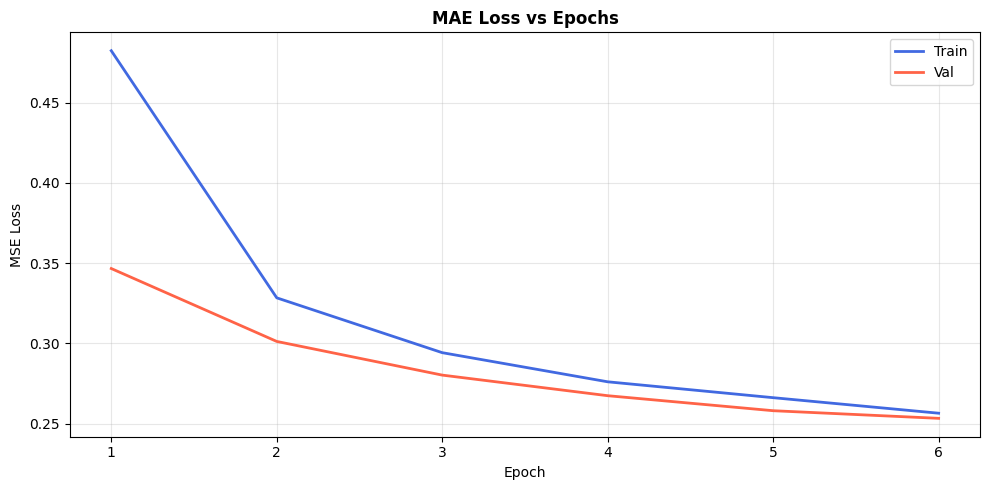

In [13]:
plt.figure(figsize=(10,5))
plt.plot(range(1,len(train_losses)+1),train_losses,label='Train',color='royalblue',lw=2)
plt.plot(range(1,len(val_losses)+1),  val_losses,  label='Val',  color='tomato',   lw=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('MAE Loss vs Epochs',fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('loss_curve.png',dpi=150); plt.show()

/tmp/ipykernel_55/3666560133.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():


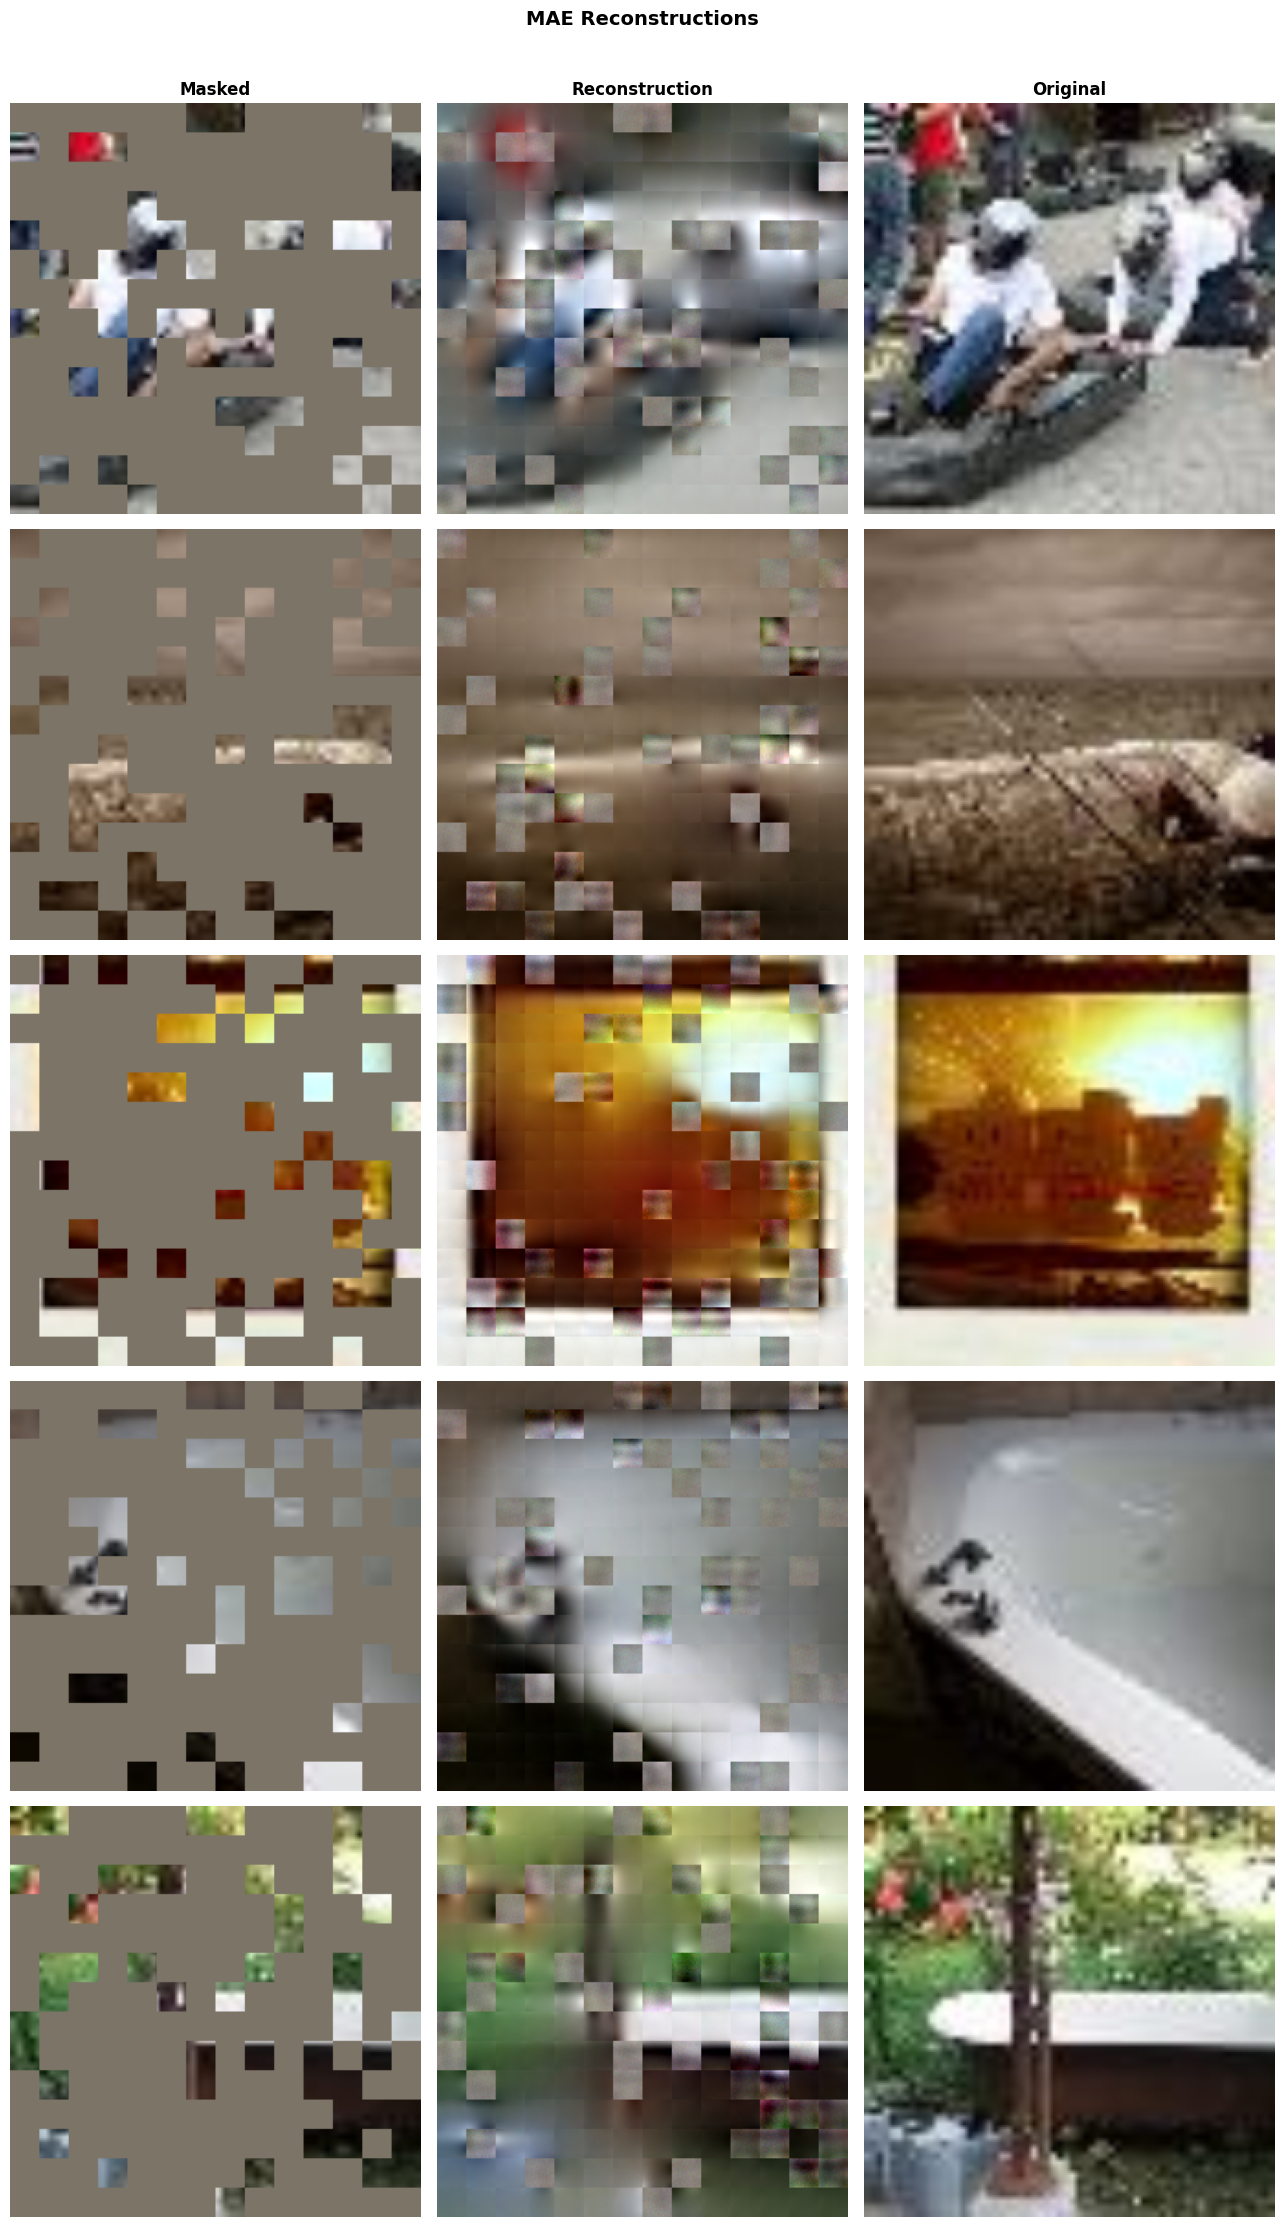

In [14]:
MEAN=torch.tensor([0.485,0.456,0.406]); STD=torch.tensor([0.229,0.224,0.225])

def denorm(t):
    t=t.cpu().float()
    for c in range(3): t[c]=t[c]*STD[c]+MEAN[c]
    return t.clamp(0,1).permute(1,2,0).numpy()

# Load best weights
model.load_state_dict(torch.load('mae_best.pth',map_location=device),strict=False)
model.eval()

imgs,_=next(iter(val_loader))
imgs=imgs[:5].to(device)
mae=get_mae(model)
with torch.no_grad(), autocast():
    _,pred,mask=mae(imgs)

pat=mae.patchify(imgs); mp=pat.clone(); mp[mask]=0.0
msk_img=mae.unpatchify(mp); rec_img=mae.unpatchify(pred.float())

fig,axes=plt.subplots(5,3,figsize=(13,22))
psnr_list,ssim_list=[],[]
for i in range(5):
    orig=denorm(imgs[i]); msk=denorm(msk_img[i]); rec=denorm(rec_img[i])
    p=calc_psnr(orig,rec,data_range=1.0)
    s=calc_ssim(orig,rec,data_range=1.0,channel_axis=2)
    psnr_list.append(p); ssim_list.append(s)
    for j,(im,tt) in enumerate(zip([msk,rec,orig],['Masked','Reconstruction','Original'])):
        axes[i,j].imshow(im); axes[i,j].axis('off')
        if i==0: axes[i,j].set_title(tt,fontsize=12,fontweight='bold')
    axes[i,1].set_xlabel(f'PSNR={p:.2f}dB | SSIM={s:.4f}',fontsize=9)

plt.suptitle('MAE Reconstructions',fontsize=14,fontweight='bold',y=1.01)
plt.tight_layout(); plt.savefig('reconstructions.png',dpi=150,bbox_inches='tight'); plt.show()

In [15]:
print('='*45)
for i,(p,s) in enumerate(zip(psnr_list,ssim_list)):
    print(f'  Sample {i+1}: PSNR={p:.2f}dB  SSIM={s:.4f}')
print(f'\n  Mean PSNR : {np.mean(psnr_list):.2f} dB')
print(f'  Mean SSIM : {np.mean(ssim_list):.4f}')
print('='*45)

  Sample 1: PSNR=14.46dB  SSIM=0.3341
  Sample 2: PSNR=18.56dB  SSIM=0.4883
  Sample 3: PSNR=15.14dB  SSIM=0.4276
  Sample 4: PSNR=18.55dB  SSIM=0.6124
  Sample 5: PSNR=15.45dB  SSIM=0.3085

  Mean PSNR : 16.43 dB
  Mean SSIM : 0.4342


In [16]:
import gradio as gr

def infer(pil_img, pct):
    if pil_img is None: return None,None,None
    tfm=transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    t=tfm(pil_img.convert('RGB')).unsqueeze(0).to(device)
    mae=get_mae(model); old=mae.mask; mae.mask=pct/100
    with torch.no_grad(),autocast(): _,pred,mask=mae(t)
    mae.mask=old
    pat=mae.patchify(t); mp=pat.clone(); mp[mask]=0.0
    def top(x): arr=denorm(x[0]); return Image.fromarray((arr*255).clip(0,255).astype(np.uint8))
    return top(mae.unpatchify(mp)), top(mae.unpatchify(pred.float())), top(t)

with gr.Blocks(title='MAE') as demo:
    gr.Markdown('# Masked Autoencoder — Image Reconstruction')
    with gr.Row():
        inp=gr.Image(type='pil',label='Upload Image')
        ratio=gr.Slider(10,90,value=75,step=5,label='Masking %')
    btn=gr.Button('Reconstruct',variant='primary')
    with gr.Row():
        o1=gr.Image(label='Masked'); o2=gr.Image(label='Reconstruction'); o3=gr.Image(label='Original')
    btn.click(infer,[inp,ratio],[o1,o2,o3])
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f30b26909223ee0f00.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
